**1.Importing Dependencies**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

In [7]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv(r"C:\Users\janin\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set images folder path
images_folder = r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\images"
os.makedirs(images_folder, exist_ok=True)

# Load dataset
df = pd.read_csv(r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

**2.Data Loading and Understanding**

In [7]:
!unzip archive.zip

Archive:  archive.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [8]:
!ls

archive.zip  drive  sample_data  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**3.Dataset Overview**

In [10]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**4.Data Cleaning and Preprocessing**

Drop irrelevant columns

In [14]:
df.drop('customerID', axis=1, inplace=True)

Fix Data Type Issues

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Handle Missing Values

In [16]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipython-input-2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**5.Target Variable Encoding**

In [17]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

**6.Categorical Feature Encoding**

In [18]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**7.Exploratory Data Analysis(EDA)**

 * **Churn Distribution**






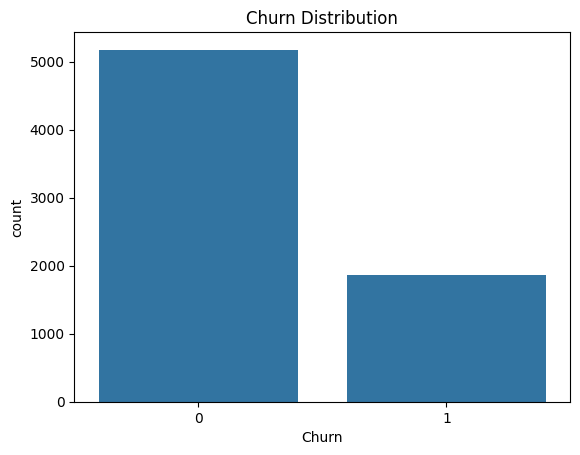

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

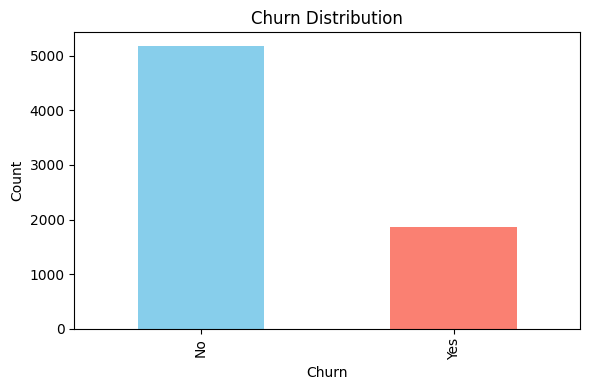

In [10]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "churn_bar_chart.png"))
plt.show()

* **Churn** **By** **Contract** **Type**

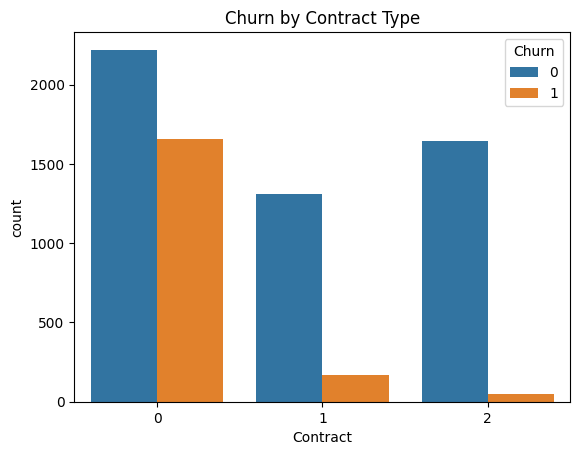

In [27]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

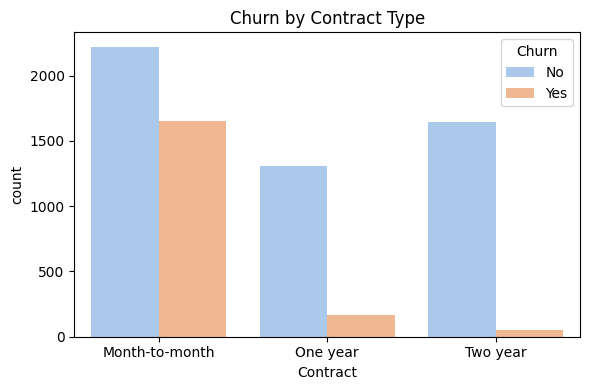

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='pastel')
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "churn_by_contract.png"))
plt.show()

* **Tenure** **vs** **Churn**

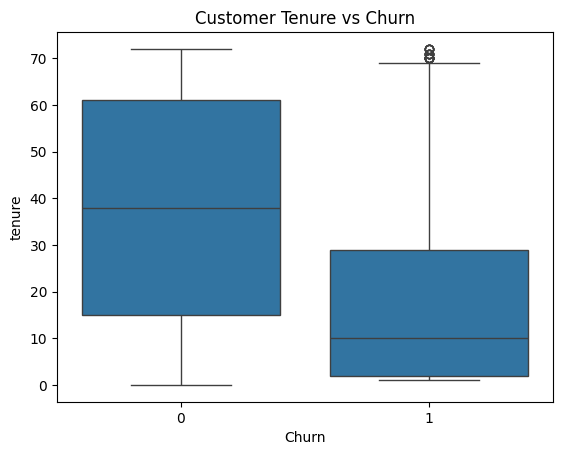

In [28]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Customer Tenure vs Churn")
plt.show()

C:\Users\janin\AppData\Local\Temp\ipykernel_14172\2402877756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')  # your existing plot


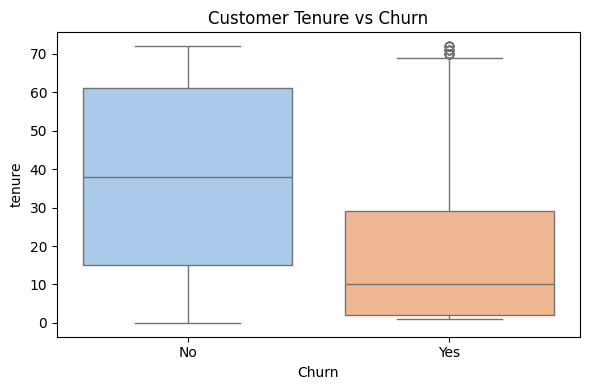

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')  # your existing plot
plt.title("Customer Tenure vs Churn")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "tenure_vs_churn.png"))  # saves image
plt.show()

* **Monthly Charges vs Churn**

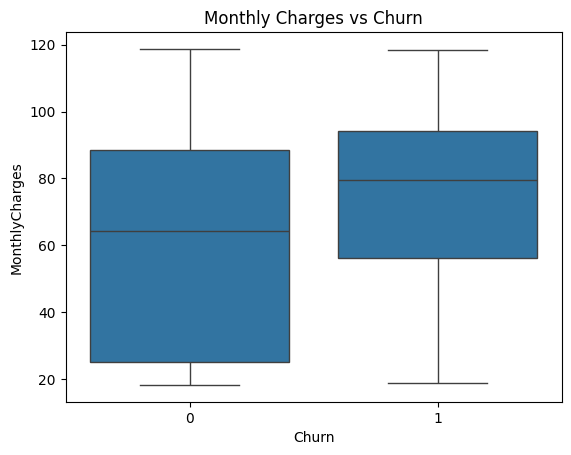

In [29]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

C:\Users\janin\AppData\Local\Temp\ipykernel_14172\3515311891.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')


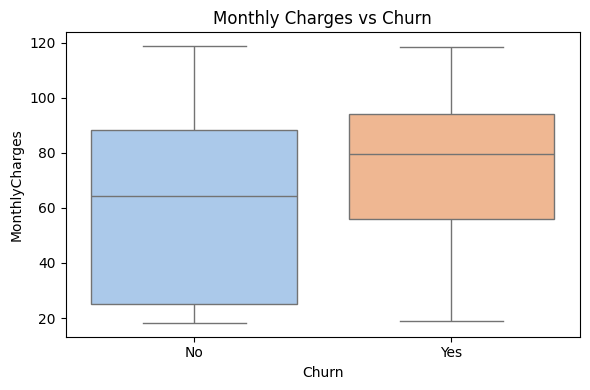

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "monthly_charges_vs_churn.png"))  # saves image
plt.show()

* **Correlation** **Heatmap**

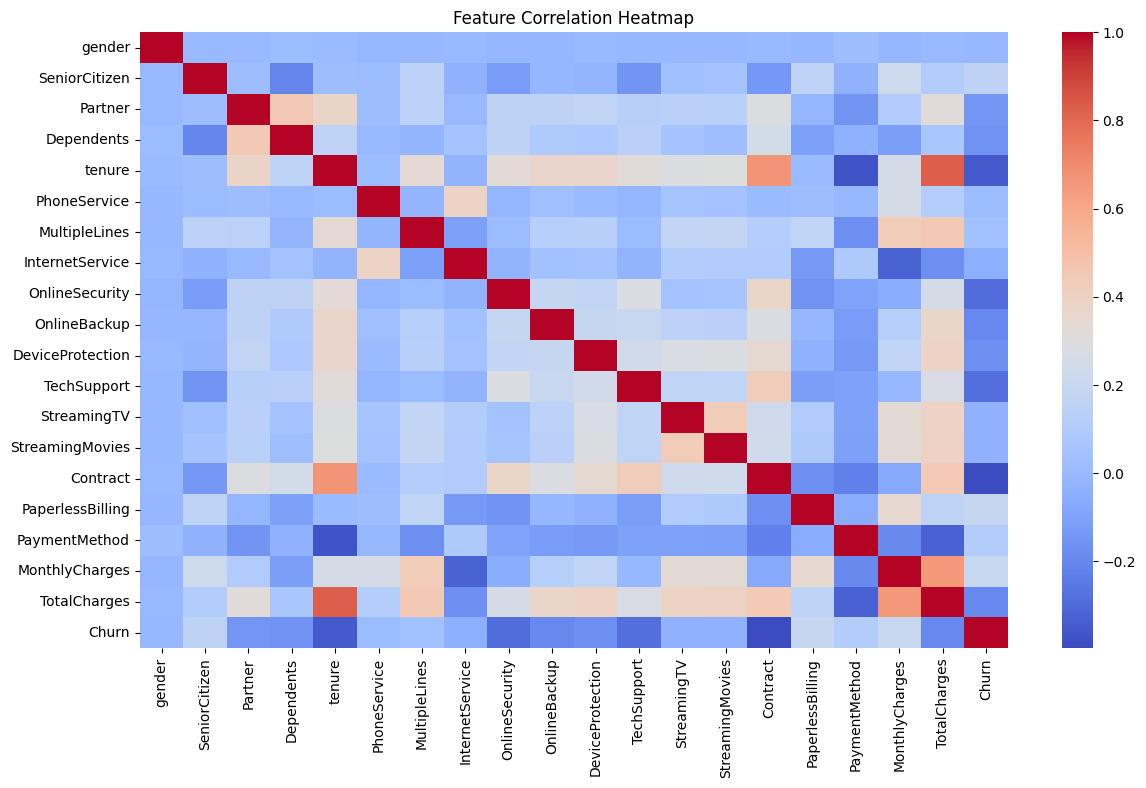

In [30]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

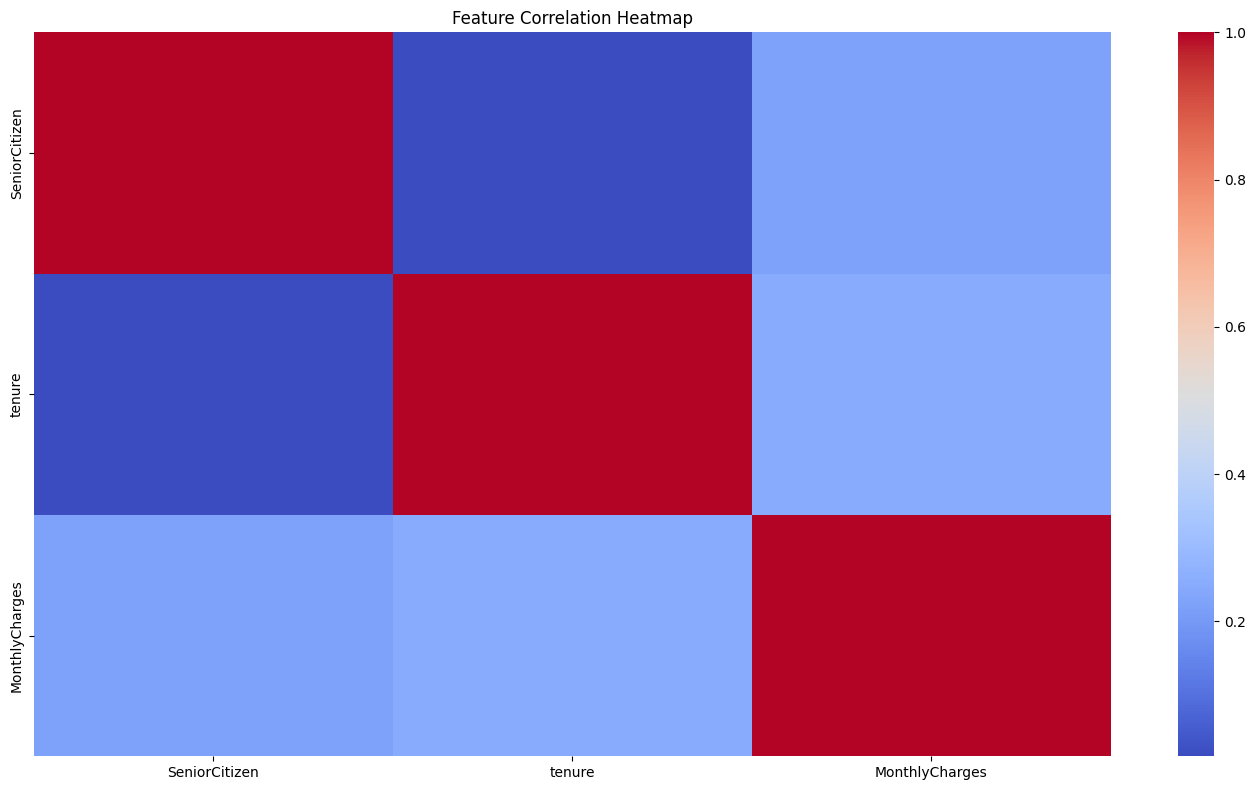

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make sure images folder exists
images_folder = r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\images"
os.makedirs(images_folder, exist_ok=True)

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "feature_correlation_heatmap.png"))  # save image
plt.show()

**8.Train-Test Split**

In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**9.Feature Scaling**

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**10.Model Building**

**i.Logistic Regression**

In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**ii.Random Forest Classifier**

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

**iii.Gradient Boosting Classifier**

In [23]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=150,
                           random_state=42)

**11.Model Evaluation**

In [24]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


Logistic Regression
Accuracy : 0.7991483321504613
F1 Score : 0.5916305916305916
ROC-AUC  : 0.8402800382340025

Random Forest
Accuracy : 0.801277501774308
F1 Score : 0.582089552238806
ROC-AUC  : 0.8362267173008862

Gradient Boosting
Accuracy : 0.8090844570617459
F1 Score : 0.5893129770992367
ROC-AUC  : 0.8454674623472578


**i**.**Evaluation** **Metrices**

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions using Random Forest (best model)
y_pred = rf.predict(X_test)

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy  : 0.801277501774308
Precision : 0.6587837837837838
Recall    : 0.5213903743315508
F1 Score  : 0.582089552238806

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



**ii**.**Confusion** **Matrix** **Visualization**

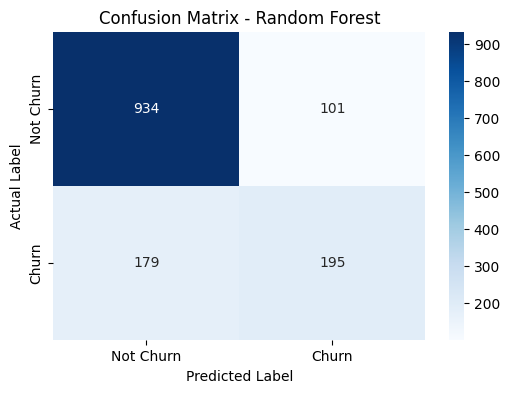

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Churn', 'Churn'],
    yticklabels=['Not Churn', 'Churn']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Confusion Matrix:
 [[957  79]
 [206 167]]


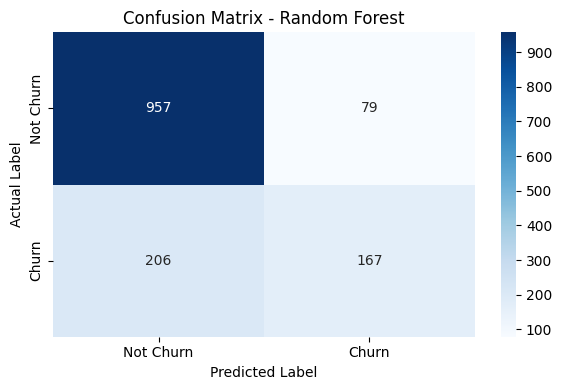

In [ ]:
--

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

#  Prepare images folder
images_folder = r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\images"
os.makedirs(images_folder, exist_ok=True)

#  Prepare features and target
# Drop customerID and target column from features
X = df.drop(columns=['customerID', 'Churn'])

# Convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Encode target column: 'Yes' -> 1, 'No' -> 0
y = df['Churn'].map({'Yes':1, 'No':0})

#  Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

#  Predict on test set
y_pred = rf_model.predict(X_test)

#  Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

#  Plot and save confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Churn', 'Churn'],
    yticklabels=['Not Churn', 'Churn']
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "confusion_matrix.png"))
plt.show()

**iii.ROC** **Curve**

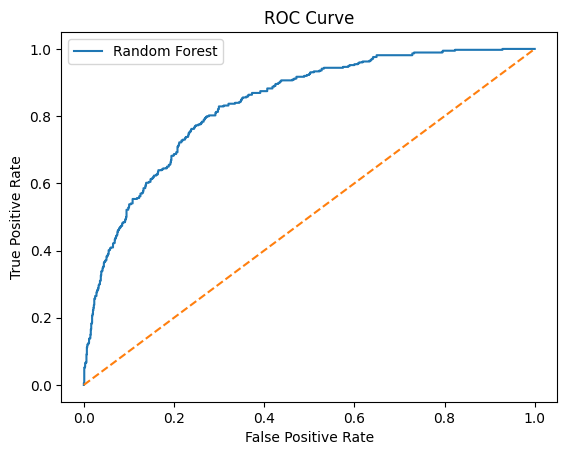

In [31]:
from sklearn.metrics import roc_curve

y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

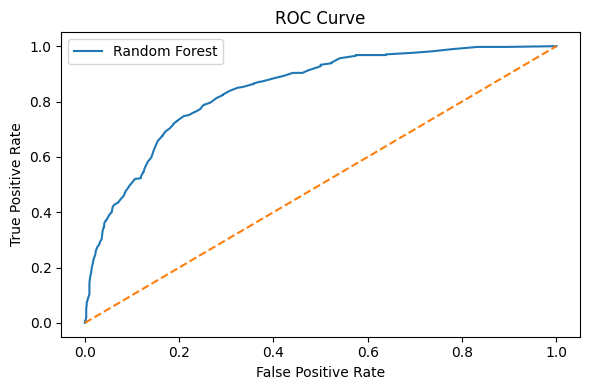

In [26]:

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

# Make sure the images folder exists
images_folder = r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\images"
os.makedirs(images_folder, exist_ok=True)

# 1️⃣ Predict probabilities for the positive class (Churn = 1)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 2️⃣ Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

# 3️⃣ Plot and save ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(images_folder, "roc_curve.png"))
plt.show()

**12.Feature Importance Analysis**

In [25]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop('Churn', axis=1).columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
tenure,0.160796
TotalCharges,0.153232
MonthlyCharges,0.142026
Contract,0.129100
OnlineSecurity,0.075669
TechSupport,0.059941
InternetService,0.044289
PaymentMethod,0.043713
OnlineBackup,0.028245
PaperlessBilling,0.025127


* **Top 10 Feature Importance Bar** **Chart**

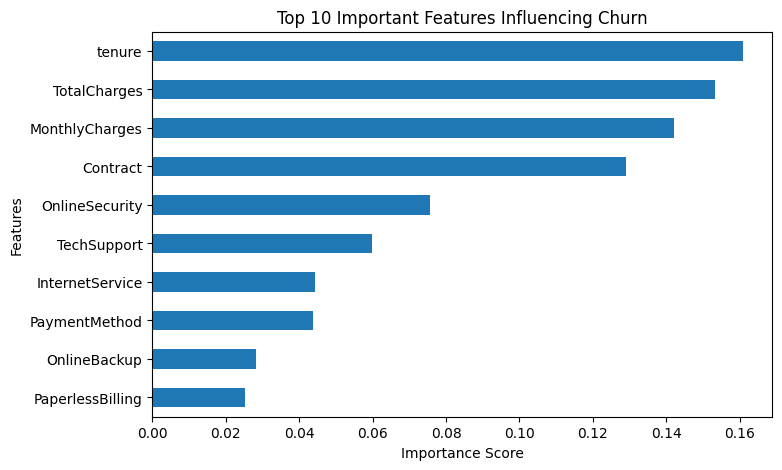

In [34]:
plt.figure(figsize=(8,5))

feature_importance.head(10).plot(
    kind='barh'
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features Influencing Churn")
plt.gca().invert_yaxis()
plt.show()

<Figure size 800x500 with 0 Axes>

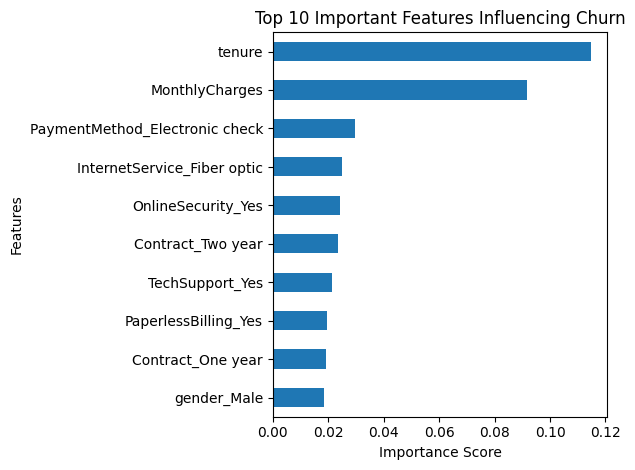

In [28]:
# -------------------------------
# Top 10 Feature Importance - Plot and Save
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import os

# Make sure images folder exists
images_folder = r"C:\Users\janin\OneDrive\Desktop\customer_churn_prediction\images"
os.makedirs(images_folder, exist_ok=True)

# 1️⃣ Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2️⃣ Plot top 10 important features
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    legend=False
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features Influencing Churn")
plt.gca().invert_yaxis()
plt.tight_layout()

# 3️⃣ Save image
plt.savefig(os.path.join(images_folder, "top10_feature_importance.png"))

# 4️⃣ Show plot
plt.show()

**13.Key Business Insights**



*   Month-to-month contract customers show higher churn risk
*   Longer tenure customers are more likely to stay

*   Customers without tech support churn more frequently






**14.Conclusion**

This project builds an end-to-end machine learning pipeline for customer churn prediction,including data preprocessing,model comparison,evaluation using business-relevant metrices, and actionable insights